# Revenue Forecasting & Price Sensitivity

## PowerGrid EV Analytics 

This notebook analyses historical EV charging revenue, investigates the relationship between charging price and demand, forecasts future monthly revenue, and evaluates pricing scenarios of +5% and -10%.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"..\..\data\raw\ev_charging_dataset.xlsx"

sessions = pd.read_excel(file_path, sheet_name="sessions")

print("Sessions shape:", sessions.shape)
sessions.head()

Sessions shape: (294024, 15)


,session_id,station_id,charger_id,charger_type,start_timestamp,end_timestamp,session_duration_minutes,energy_kwh,price_per_kwh,total_cost,payment_method,user_type,customer_id,station_region,year
0,S_00000001,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 08:30:00,2022-01-01 08:56:00,26,56.9,0.47,26.74,app,fleet,CUST_00134,North West,2022
1,S_00000002,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 09:20:00,2022-01-01 09:41:00,21,40.7,0.46,18.72,app,delivery,CUST_00195,North West,2022
2,S_00000003,STN_001,STN_001_CH_04,DC_50kW,2022-01-01 09:00:00,2022-01-01 09:48:00,48,30.9,0.47,14.52,rfid,public,CUST_01935,North West,2022
3,S_00000004,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 23:20:00,2022-01-02 00:01:00,41,28.4,0.45,12.78,rfid,public,CUST_00036,North West,2022
4,S_00000005,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 16:10:00,2022-01-01 17:00:00,50,31.7,0.56,17.75,rfid,taxi,CUST_00011,North West,2022


In [4]:
# Convert timestamps to datetime
sessions["start_timestamp"] = pd.to_datetime(sessions["start_timestamp"])

# Create a month column
sessions["month"] = sessions["start_timestamp"].dt.to_period("M")

# Aggregate revenue and energy by month
monthly_revenue = (
    sessions.groupby("month")
    .agg(
        revenue=("total_cost", "sum"),
        energy_kwh=("energy_kwh", "sum"),
        sessions=("session_id", "count"),
        avg_price_per_kwh=("price_per_kwh", "mean")
    )
    .reset_index()
)

# Convert month back to timestamp for plotting/forecasting
monthly_revenue["month"] = monthly_revenue["month"].dt.to_timestamp()

monthly_revenue.head()

,month,revenue,energy_kwh,sessions,avg_price_per_kwh
0,2022-01-01,85420.18,167166.3,3394,0.510719
1,2022-02-01,79489.65,155708.9,3120,0.510420
2,2022-03-01,88864.54,173678.2,3497,0.511567
3,2022-04-01,83737.74,164041.3,3349,0.510681
4,2022-05-01,88598.22,172824.0,3497,0.512714


In [5]:
monthly_revenue.shape

(36, 5)

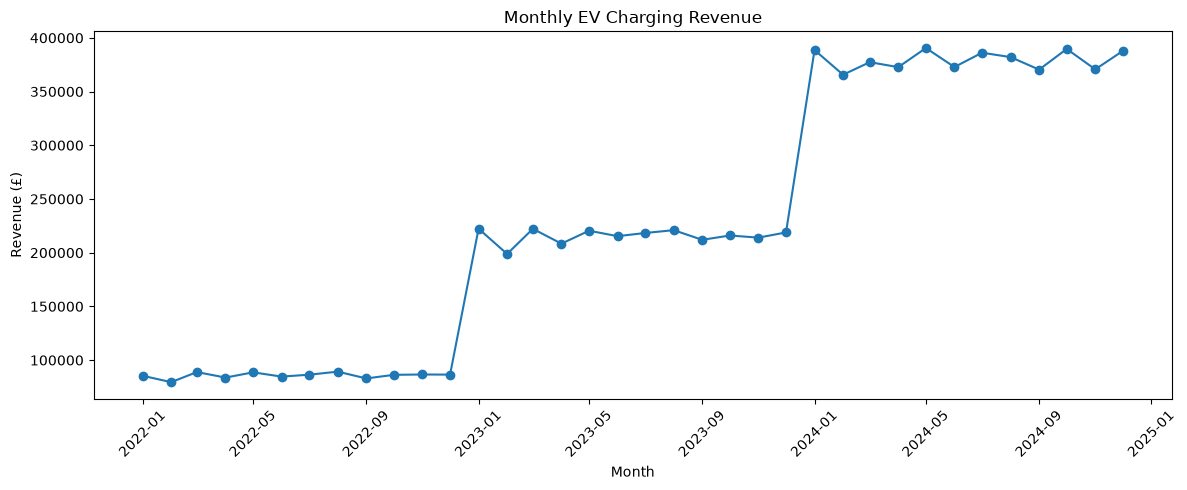

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly EV Charging Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
annual_revenue = (
    monthly_revenue
    .assign(year=monthly_revenue["month"].dt.year)
    .groupby("year")
    .agg(
        revenue=("revenue", "sum"),
        energy_kwh=("energy_kwh", "sum"),
        sessions=("sessions", "sum")
    )
    .reset_index()
)

annual_revenue["revenue_growth_%"] = (
    annual_revenue["revenue"].pct_change() * 100
)

annual_revenue

,year,revenue,energy_kwh,sessions,revenue_growth_%
0,2022,1028771.80,2011828.0,40640,NaN
1,2023,2587773.92,4049124.5,86132,151.540130
2,2024,4554554.40,7747793.3,167252,76.002794


In [8]:
monthly_revenue["weighted_price_per_kwh"] = (
    monthly_revenue["revenue"] / monthly_revenue["energy_kwh"]
)

monthly_revenue[
    ["month", "revenue", "energy_kwh", "weighted_price_per_kwh"]
]

,month,revenue,energy_kwh,weighted_price_per_kwh
0,2022-01-01,85420.18,167166.3,0.510989
1,2022-02-01,79489.65,155708.9,0.510502
2,2022-03-01,88864.54,173678.2,0.511662
3,2022-04-01,83737.74,164041.3,0.510467
4,2022-05-01,88598.22,172824.0,0.512650
5,2022-06-01,84659.34,165544.1,0.511401
6,2022-07-01,86412.76,168716.2,0.512178
7,2022-08-01,89249.73,175107.3,0.509686
8,2022-09-01,82940.02,161900.3,0.512291
9,2022-10-01,86294.16,168846.0,0.511082


In [9]:
import statsmodels.api as sm

# Log-transform price and demand
elasticity_data = monthly_revenue[
    ["energy_kwh", "weighted_price_per_kwh"]
].copy()

elasticity_data["log_energy"] = np.log(elasticity_data["energy_kwh"])
elasticity_data["log_price"] = np.log(elasticity_data["weighted_price_per_kwh"])

# Regression: log demand ~ log price
X = sm.add_constant(elasticity_data["log_price"])
y = elasticity_data["log_energy"]

elasticity_model = sm.OLS(y, X).fit()

print(elasticity_model.summary())
print("\nPrice Elasticity:", elasticity_model.params["log_price"])

                            OLS Regression Results                            
Dep. Variable:             log_energy   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     22.93
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           3.22e-05
Time:                        19:39:53   Log-Likelihood:                -20.375
No. Observations:                  36   AIC:                             44.75
Df Residuals:                      34   BIC:                             47.92
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.8038      0.443     33.421      0.0

In [10]:
price_check = sessions.groupby(
    ["year", "charger_type"]
).agg(
    avg_price=("price_per_kwh", "mean"),
    min_price=("price_per_kwh", "min"),
    max_price=("price_per_kwh", "max"),
    unique_prices=("price_per_kwh", "nunique")
).reset_index()

price_check

,year,charger_type,avg_price,min_price,max_price,unique_prices
0,2022,DC_150kW,0.511200,0.45,0.63,19
1,2022,DC_300kW,0.511346,0.45,0.63,19
2,2022,DC_50kW,0.511596,0.45,0.63,19
3,2023,DC_150kW,0.638472,0.55,0.80,26
4,2023,DC_300kW,0.639528,0.55,0.80,26
5,2023,DC_50kW,0.639275,0.55,0.80,26
6,2024,DC_150kW,0.588080,0.50,0.75,26
7,2024,DC_300kW,0.587515,0.50,0.75,26
8,2024,DC_50kW,0.587937,0.50,0.75,26


In [11]:
elasticity_data = monthly_revenue.copy()

elasticity_data["year"] = elasticity_data["month"].dt.year

elasticity_data["log_energy"] = np.log(elasticity_data["energy_kwh"])
elasticity_data["log_price"] = np.log(elasticity_data["weighted_price_per_kwh"])

# Create year dummy variables
elasticity_data = pd.get_dummies(
    elasticity_data,
    columns=["year"],
    drop_first=True
)

X = elasticity_data[
    ["log_price", "year_2023", "year_2024"]
]

X = sm.add_constant(X).astype(float)

y = elasticity_data["log_energy"]

elasticity_model_controlled = sm.OLS(y, X).fit()

print(elasticity_model_controlled.summary())
print(
    "\nControlled Price Elasticity:",
    elasticity_model_controlled.params["log_price"]
)

                            OLS Regression Results                            
Dep. Variable:             log_energy   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     3996.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           2.93e-41
Time:                        19:42:40   Log-Likelihood:                 77.063
No. Observations:                  36   AIC:                            -146.1
Df Residuals:                      32   BIC:                            -139.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.5321      2.720      4.608      0.0

In [12]:
# Extract estimated elasticity
elasticity = elasticity_model_controlled.params["log_price"]

# Scenario price changes
scenarios = pd.DataFrame({
    "scenario": ["Baseline", "Price +5%", "Price -10%"],
    "price_change": [0.00, 0.05, -0.10]
})

# Estimate demand response using elasticity
scenarios["demand_multiplier"] = (
    1 + scenarios["price_change"]
) ** elasticity

# Revenue multiplier = price multiplier × demand multiplier
scenarios["revenue_multiplier"] = (
    (1 + scenarios["price_change"])
    * scenarios["demand_multiplier"]
)

scenarios["estimated_demand_change_%"] = (
    (scenarios["demand_multiplier"] - 1) * 100
)

scenarios["estimated_revenue_change_%"] = (
    (scenarios["revenue_multiplier"] - 1) * 100
)

scenarios

,scenario,price_change,demand_multiplier,revenue_multiplier,estimated_demand_change_%,estimated_revenue_change_%
0,Baseline,0.00,1.000000,1.000000,0.000000,0.00000
1,Price +5%,0.05,1.037262,1.089125,3.726153,8.91246
2,Price -10%,-0.10,0.924038,0.831634,-7.596189,-16.83657


In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Use the first 30 months for training
train = monthly_revenue.iloc[:-6].copy()
test = monthly_revenue.iloc[-6:].copy()

print("Training period:", train["month"].min(), "to", train["month"].max())
print("Test period:", test["month"].min(), "to", test["month"].max())

Training period: 2022-01-01 00:00:00 to 2024-06-01 00:00:00
Test period: 2024-07-01 00:00:00 to 2024-12-01 00:00:00


In [14]:
# Fit Holt-Winters Exponential Smoothing model
model = ExponentialSmoothing(
    train["revenue"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fitted_model = model.fit(optimized=True)

# Forecast the 6 test months
test_forecast = fitted_model.forecast(len(test))

# Evaluate forecast accuracy
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(test["revenue"], test_forecast)
rmse = np.sqrt(mean_squared_error(test["revenue"], test_forecast))

print(f"MAE: £{mae:,.2f}")
print(f"RMSE: £{rmse:,.2f}")

MAE: £6,727.27
RMSE: £8,110.73


In [15]:
# Fit the final model using all available historical data
final_model = ExponentialSmoothing(
    monthly_revenue["revenue"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

final_fitted_model = final_model.fit(optimized=True)

# Forecast next 12 months
future_forecast = final_fitted_model.forecast(12)

# Create a clean forecast table
forecast_dates = pd.date_range(
    start=monthly_revenue["month"].max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

revenue_forecast = pd.DataFrame({
    "month": forecast_dates,
    "forecast_revenue": future_forecast.values
})

revenue_forecast

,month,forecast_revenue
0,2025-01-01,525534.783121
1,2025-02-01,509669.883918
2,2025-03-01,534288.374002
3,2025-04-01,529497.146398
4,2025-05-01,544176.483005
5,2025-06-01,537029.471807
6,2025-07-01,544695.783162
7,2025-08-01,545380.716496
8,2025-09-01,537721.961402
9,2025-10-01,545559.158584


In [16]:
forecast_summary = {
    "2025_total_forecast_revenue": revenue_forecast["forecast_revenue"].sum(),
    "2025_average_monthly_revenue": revenue_forecast["forecast_revenue"].mean(),
    "2025_min_monthly_revenue": revenue_forecast["forecast_revenue"].min(),
    "2025_max_monthly_revenue": revenue_forecast["forecast_revenue"].max()
}

for metric, value in forecast_summary.items():
    print(f"{metric}: £{value:,.2f}")

2025_total_forecast_revenue: £6,434,243.44
2025_average_monthly_revenue: £536,186.95
2025_min_monthly_revenue: £509,669.88
2025_max_monthly_revenue: £545,559.16


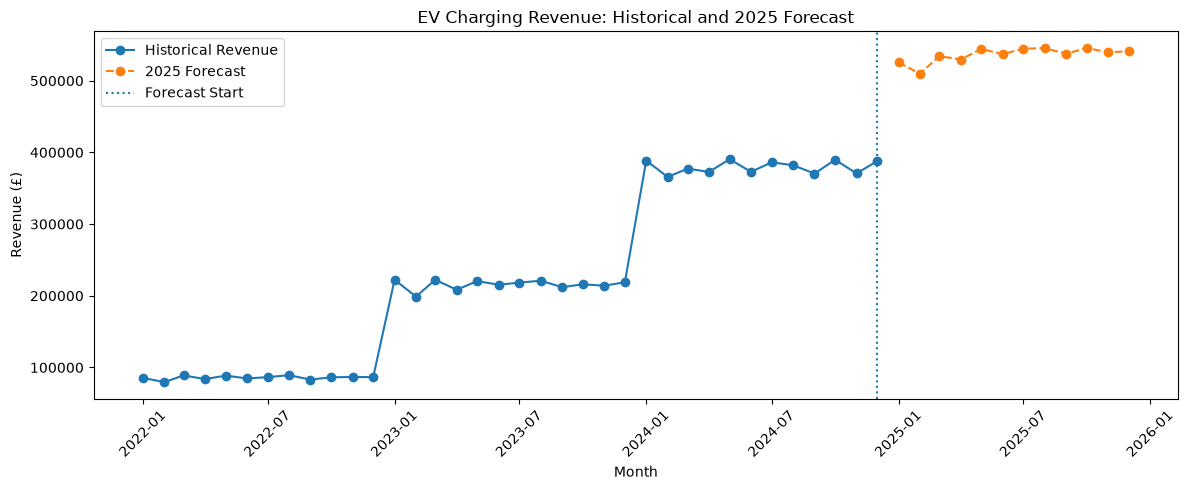

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o",
    label="Historical Revenue"
)

plt.plot(
    revenue_forecast["month"],
    revenue_forecast["forecast_revenue"],
    marker="o",
    linestyle="--",
    label="2025 Forecast"
)

plt.axvline(
    monthly_revenue["month"].max(),
    linestyle=":",
    label="Forecast Start"
)

plt.title("EV Charging Revenue: Historical and 2025 Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Save datasets for Power BI

output_path = r"..\..\tasks\task_02_revenue_price_sensitivity\powerbi"

monthly_revenue.to_csv(
    output_path + r"\monthly_revenue.csv",
    index=False
)

revenue_forecast.to_csv(
    output_path + r"\revenue_forecast.csv",
    index=False
)

scenarios.to_csv(
    output_path + r"\pricing_scenarios.csv",
    index=False
)
